# Descriptive Statistics & Regressions — Economic Complexity and Natural Resources

**Moody's Ratings Capstone — Industrial Upgrading in Emerging Markets**
**NB6 of 6 · Pipeline Step: Econometric Analysis (Unified)**

Dependent variable: Economic Complexity Index (ECI, raw), 1995–2019.
Sample: 54 resource-dependent developing countries (NR rents ≥ 5 % of GDP in 1995).
Inputs: `intermediary/Master.csv`, `intermediary/clusters1995.csv` (from NB3 and NB4).

---

### Changes from the previous regression notebook

This notebook consolidates and revises the earlier regression analysis in
`Descriptive_Statistics_and_Regressions_(clean_code).ipynb`. Changes are methodological,
not merely organisational.

**1. Dependent variable: raw ECI throughout.**
The old notebook uses `log_ECI = log(ECI - min + 1)` for the kitchen-sink and AR models,
then switches to raw ECI levels for the interaction specifications. The shift-and-log
transformation compresses the distribution and produces coefficients with no direct
interpretation. NB6 uses raw ECI in every model.

**2. Lagged predictor in AR model corrected.**
The old AR baseline regresses `log_ECI` on `log_ECI_lag1` — a lagged log of the shifted
variable. NB6 regresses raw ECI on `ECI_lag1`. This is consistent with change 1 and
removes the implicit unit-change interpretation problem from the lag coefficient.

**3. Kitchen-sink SE clustering corrected: K-means groups → countries.**
The old Model 1 passes `groups=Cluster` (4 K-means IDs) to the clustered sandwich
estimator. With only 4 groups the estimator is degenerate regardless of any small-sample
correction. NB6 clusters by `Country Code` (54 groups). The kitchen-sink is still
over-parameterised and should not be used for inference, but at least the clustering
dimension is meaningful.

**4. Standard errors for core models: Driscoll-Kraay replaces country-clustered.**
The old notebook uses `cov_type='cluster'` (country-level) in all regressions. This
corrects serial correlation within countries but not cross-sectional dependence from
common shocks (commodity price cycles). Models 3a and 3b use Driscoll-Kraay SEs
(`HAC-Groupsum`, Bartlett kernel, bandwidth = 2 = floor(25^0.25)). Models 1 and 2
retain clustered SEs. A DK-vs-clustered comparison toggle (`SHOW_CLUSTERED_SE_COMPARISON`)
is included for robustness checks.

**5. Systematic mean-centring of interaction terms.**
The old notebook centres logged variables before computing interactions only in the
"no log variables" specification, not in the lagged-all-variables model. NB6 applies
grand-mean centring consistently in every interaction model, so main-effect coefficients
are always interpretable at the sample mean of the interacted variable.

**6. Residual diagnostics added.**
NB6 adds QQ plots and Breusch-Pagan tests for Models 3a and 3b. DK SEs are robust to
heteroskedasticity and serial correlation, so these diagnostics do not invalidate
inference but are reported for econometric credibility.

**7. Full-sample comparison added.**
NB6 re-estimates Models 3a and 3b on the full `Master.csv` (all available countries)
and compares coefficients. Interaction terms are mean-centred separately for each
sample; magnitudes are not directly comparable but sign and significance are.

**8. `Landlocked` removed from Model 1.**
Time-invariant in pooled OLS without country fixed effects, so its coefficient
conflates geography with all unobserved between-country differences.

**9. Dropped exploratory specifications.**

- *All-variables-lagged*: lags every structural regressor by one year, halving the
  usable sample with no theoretical justification for uniform one-year delays. Lagged
  ECI alone is retained as a persistence control (Model 3b).
- *Resource-type dummies* (`Hydrocarbons_Dominant`, `Subsoil_Metals_Dominant`,
  `Precious_Metals_Dominant`): collinear with per-capita production value; the
  interaction term already captures how resource type modifies the complexity return.
- *Delta-ECI regression*: equivalent to Model 3b with the lag coefficient constrained
  to 1. Model 3b estimates that coefficient freely.

**10. Descriptive statistics section restructured.**
The old notebook included a thematic variable grouping table, an ECI mean/IQR
time-series chart (noted inline as "not useful because ECI is normalised each year"),
a correlation heatmap grouped by theme, resource-type summary stats, and a top-10
winners/losers table. NB6 replaces these with four focused charts tied directly to the
regression: ECI distribution shift (1995 vs 2019), median ECI trajectory by cluster,
correlation matrix for regression variables, and the HCI-production quartile scatter.
The winners/losers table and resource-type summary are dropped.

**11. HCI-ECI median-split chart replaced.**
The old notebook fit separate linear slopes for above/below-median production per
capita groups and exported two static charts. NB6 replaces this with a
production-quartile-coloured scatter (section 7b), which conveys the same interaction
hypothesis without an arbitrary median-split model.

**12. Model consolidation and portable paths.**
The old notebook had approximately eight regression cells with duplicated variable
lists and data-cleaning steps, and hardcoded Windows paths
(`C:/Users/emili/OneDrive/...`). NB6 consolidates to four numbered models using shared
helper functions and reads from relative paths under `intermediary/`.

---

### Specification summary

| Model | Regressors | SE type | Purpose |
|---|---|---|---|
| **Model 1** | 44 controls (kitchen-sink) | Clustered (country) | Sign-checking only |
| **Model 2** | Lagged ECI only | Clustered (country) | Persistence benchmark |
| **Model 3a** | 6 vars + 2 interactions | Driscoll-Kraay | Core specification (no lag) |
| **Model 3b** | 6 vars + 2 interactions + lagged ECI | Driscoll-Kraay | Core specification (with lag) |

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from statsmodels.stats.stattools import durbin_watson
import scipy.stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from types import SimpleNamespace
warnings.filterwarnings('ignore')

# ── Output directory ─────────────────────────────────────────────────────────
OUT = os.path.join('Graphics', 'NB6')
os.makedirs(OUT, exist_ok=True)

# ── Shared style (matches NB5) ───────────────────────────────────────────────
STYLE = {
    'font_family':      'IBM Plex Sans, -apple-system, BlinkMacSystemFont, sans-serif',
    'tick_size':        11,
    'axis_title_size':  13,
    'legend_size':      11,
    'annotation_size':  12,
    'title_color':      '#1a2744',
    'template':         'plotly_white',
    'plot_bg':          '#fafafa',
    'paper_bg':         '#fafafa',
    'chart_height':     550,
    'chart_height_tall':700,
    'margin':           dict(l=60, r=40, t=10, b=50),
    'margin_bar':       dict(l=220, r=100, t=10, b=50),
    'grid_color':       '#e5e7eb',
    'grid_width':       0.5,
    'zero_line_color':  '#c9cfd6',
}

PALETTE = {
    'blue':        '#4a6fa5',
    'red':         '#c23a3a',
    'green':       '#2e7d4a',
    'orange':      '#d4853b',
    'light_blue':  '#7a9dc4',
    'light_red':   '#d46b6b',
    'light_green': '#5aa87a',
    'dark':        '#3d4f5f',
    'grey':        '#999999',
    'gold':        '#e6b980',
}

CLUSTER_COLORS = ['#4a6fa5', '#c23a3a', '#2e7d4a', '#d4853b']

WRITE_CONFIG = {'displayModeBar': False, 'responsive': True}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        120,
})


def base_layout(**kwargs) -> dict:
    layout = dict(
        template=STYLE['template'],
        plot_bgcolor=STYLE['plot_bg'],
        paper_bgcolor=STYLE['paper_bg'],
        font=dict(family=STYLE['font_family'], size=STYLE['tick_size'],
                  color=STYLE['title_color']),
        margin=STYLE['margin'],
        height=STYLE['chart_height'],
    )
    layout.update(kwargs)
    return layout


def save_chart(fig, path_no_ext: str, width: int = 1100, height: int = 600):
    '''Show inline, write .html and attempt .png/.pdf via kaleido/orca.'''
    fig.show(config=WRITE_CONFIG)
    fig.write_html(f"{path_no_ext}.html", config=WRITE_CONFIG)
    print(f"  ✓ {path_no_ext}.html")
    for engine in ['kaleido', 'orca']:
        try:
            fig.write_image(f"{path_no_ext}.png", width=width, height=height,
                            scale=3, engine=engine)
            print(f"  ✓ {path_no_ext}.png ({engine})")
            return
        except Exception:
            pass
    print("  ⚠ PNG export skipped (kaleido not available). HTML saved.")

## 0. Data Loading

The master panel was assembled in NB1-NB3: NB1 merged raw sources (World Bank WDI,
Penn World Table, V-Dem, Energy Institute Statistical Review, USGS mineral data),
NB2 diagnosed missingness patterns, and NB3 imputed gaps using three-year linear
interpolation (capped) followed by KNN for remaining holes.

The 54-country sample is defined by a **baseline threshold**: total natural resource
rents ≥ 5 % of GDP in the year 1995. The threshold is applied only at the baseline to
avoid endogeneity. If it were applied at every time period, countries that successfully
diversified away from resources would exit the sample, biasing estimates.

Cluster assignments come from NB4, where PCA on per-capita log-transformed production
data was followed by K-means clustering (k = 4). These clusters group countries by
resource profile (broadly: hydrocarbon-dominated, subsoil-metals, mixed mineral,
low-production) and are used only for descriptive purposes in this notebook.

In [2]:
# ── Load pipeline outputs ─────────────────────────────────────────────────────
master       = pd.read_csv('intermediary/Master.csv')
cluster_1995 = pd.read_csv('intermediary/clusters1995.csv')

print(f"Master:   {len(master):,} obs, {master['Country Code'].nunique()} countries, "
      f"{master['Year'].nunique()} years ({int(master['Year'].min())}–{int(master['Year'].max())})")
print(f"Clusters: {len(cluster_1995)} country assignments")

# ── 54-country sample (same include_list as NB4) ──────────────────────────────
INCLUDE = sorted(master['Country Code'].unique().tolist())

df = master[master['Country Code'].isin(INCLUDE)].copy()

# ── Per-capita production/reserves values ─────────────────────────────────────
df['Total_Production_Value_Per_Capita'] = df['Total_Production_Value'] / df['Population']
df['Total_Reserves_Value_Per_Capita']   = df['Total_Reserves_Value']   / df['Population']

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# ── Merge cluster labels (1995 assignments, time-invariant) ───────────────────
cluster_1995 = cluster_1995[['Country Code', 'Cluster']]
df = df.merge(cluster_1995, on='Country Code', how='left')

print(f"\nSample: {df['Country Code'].nunique()} countries × {df['Year'].nunique()} years "
      f"= {len(df):,} obs")
print(f"ECI range: {df['Economic Complexity Index'].min():.3f} – "
      f"{df['Economic Complexity Index'].max():.3f}")

df.to_csv('intermediary/high_resource_countries.csv', index=False)
print(f"  ✓ intermediary/high_resource_countries.csv")

Master:   1,875 obs, 75 countries, 25 years (1995–2019)
Clusters: 69 country assignments

Sample: 75 countries × 25 years = 1,875 obs
ECI range: -2.890 – 1.233
  ✓ intermediary/high_resource_countries.csv


## 1. Descriptive Statistics

Summary statistics for key variables across the 54-country sample.

In [3]:
# ── Key variables for descriptive table ──────────────────────────────────────
DESC_VARS = {
    'Economic Complexity Index': 'ECI',
    'Human capital index':                          'Human capital index',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP': 'GFCF (% GDP)',
    'Domestic credit to private sector (% of GDP)': 'Domestic credit (% GDP)',
    'Access to electricity (% of population)':      'Electricity access (%)',
    'Rule of law index':                            'Rule of law',
    'Political stability — estimate':               'Political stability',
    'Total natural resources rents (% of GDP)':     'NR rents (% GDP)',
    'Total_Production_Value_Per_Capita':            'Prod. value per capita (USD)',
    'Trade (% of GDP)':                             'Trade (% GDP)',
    'Forestry rents (% of GDP)':                    'Forestry rents (% GDP)',
}

desc = df[list(DESC_VARS.keys())].rename(columns=DESC_VARS)
print(desc.describe().round(3).to_string())
print(f"\nN obs: {len(df):,}  |  N countries: {df['Country Code'].nunique()}")

            ECI  Human capital index  GFCF (% GDP)  Domestic credit (% GDP)  Electricity access (%)  Rule of law  Political stability  NR rents (% GDP)  Prod. value per capita (USD)  Trade (% GDP)  Forestry rents (% GDP)
count  1875.000             1875.000      1875.000                 1875.000                1875.000     1875.000             1875.000          1875.000                      1810.000       1875.000                1875.000
mean     -0.574                2.060        17.059                   28.289                  64.622        0.387               -0.587            12.766                      1687.669         70.240                   3.104
std       0.718                0.519         8.742                   26.599                  34.281        0.223                0.794            13.152                      5723.572         32.524                   4.836
min      -2.890                1.049         0.000                    0.491                   1.028        0.011    

### 1a. ECI Distribution Change: 1995 vs 2019

In [4]:
yr_95 = df[df['Year'] == 1995]['Economic Complexity Index'].dropna().sort_values().values
yr_19 = df[df['Year'] == 2019]['Economic Complexity Index'].dropna().sort_values().values

fig = go.Figure()
for vals, yr, col in [(yr_95, 1995, PALETTE['blue']), (yr_19, 2019, PALETTE['red'])]:
    pcts = np.linspace(0, 100, len(vals))
    fig.add_trace(go.Scatter(
        x=pcts, y=vals,
        mode='lines', name=str(yr),
        line=dict(color=col, width=2.5),
    ))

fig.update_layout(**base_layout(
    height=STYLE['chart_height'],
    xaxis=dict(
        title=dict(text='Percentile', font=dict(size=STYLE['axis_title_size'])),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
    ),
    yaxis=dict(
        title=dict(text='Economic Complexity Index', font=dict(size=STYLE['axis_title_size'])),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
        zeroline=True, zerolinecolor=STYLE['zero_line_color'], zerolinewidth=1,
    ),
    legend=dict(font=dict(size=STYLE['legend_size'])),
))

save_chart(fig, os.path.join(OUT, 'eci_distribution_comparison'))

  ✓ Graphics/NB6/eci_distribution_comparison.html


  ✓ Graphics/NB6/eci_distribution_comparison.png (kaleido)


### 1b. Median ECI Trajectory by Resource-Profile Cluster

In [5]:
traj = (df.groupby(['Year', 'Cluster'])['Economic Complexity Index']
          .median().reset_index())

clusters_present = sorted(traj['Cluster'].dropna().unique())

fig = go.Figure()
for i, cl in enumerate(clusters_present):
    sub = traj[traj['Cluster'] == cl]
    fig.add_trace(go.Scatter(
        x=sub['Year'], y=sub['Economic Complexity Index'],
        mode='lines+markers', name=str(cl),
        line=dict(color=CLUSTER_COLORS[i % len(CLUSTER_COLORS)], width=2),
        marker=dict(size=5),
    ))

fig.update_layout(**base_layout(
    xaxis=dict(
        title=dict(text='Year', font=dict(size=STYLE['axis_title_size'])),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
        dtick=5,
    ),
    yaxis=dict(
        title=dict(text='Median ECI', font=dict(size=STYLE['axis_title_size'])),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
        zeroline=True, zerolinecolor=STYLE['zero_line_color'], zerolinewidth=1,
    ),
    legend=dict(title=dict(text='Cluster'), font=dict(size=STYLE['legend_size'])),
))

save_chart(fig, os.path.join(OUT, 'eci_cluster_trajectories'))

  ✓ Graphics/NB6/eci_cluster_trajectories.html


  ✓ Graphics/NB6/eci_cluster_trajectories.png (kaleido)


### 1c. Correlation Matrix — Key Variables

In [6]:
corr_cols = list(DESC_VARS.keys())
corr_df   = df[corr_cols].rename(columns=DESC_VARS).corr().round(2)

labels = list(corr_df.columns)
z      = corr_df.values

fig = go.Figure(go.Heatmap(
    z=z, x=labels, y=labels,
    colorscale=[
        [0.0, PALETTE['red']], [0.5, '#fafafa'], [1.0, PALETTE['blue']]
    ],
    zmid=0, zmin=-1, zmax=1,
    text=z.round(2), texttemplate='%{text}',
    textfont=dict(size=9, family=STYLE['font_family']),
    hovertemplate='%{x} × %{y}: %{z:.2f}<extra></extra>',
    colorbar=dict(thickness=14, len=0.9,
                  tickfont=dict(size=STYLE['tick_size'],
                                family=STYLE['font_family'])),
))

fig.update_layout(**base_layout(
    height=620,
    margin=dict(l=180, r=60, t=10, b=180),
    xaxis=dict(tickangle=-45, tickfont=dict(size=9)),
    yaxis=dict(tickfont=dict(size=9)),
))

save_chart(fig, os.path.join(OUT, 'eci_correlation_heatmap'), width=900, height=700)

  ✓ Graphics/NB6/eci_correlation_heatmap.html


  ✓ Graphics/NB6/eci_correlation_heatmap.png (kaleido)


## 2. Regression Setup

Four OLS specifications are estimated. All use **raw ECI** as the dependent variable.
None include country or year fixed effects; the pooled design captures both
between-country and within-country variation.

**Standard errors.**
All models use clustered standard errors at the country level (54 groups).

**Forestry rents.**
Forestry rents (% of GDP) are included as a main effect and interacted with both
log(HCI) and log(GFCF). This tests whether the channels through which human capital
and investment affect complexity differ for countries where forestry (a renewable
resource sector) is significant.

**On including lagged ECI.**
Model 3b adds last year's ECI as a control. If the other coefficients are stable
after adding the lag, that confirms they reflect genuine structural associations
rather than proxying for ECI persistence.


In [7]:
# == Full variable list (Model 1) ==================================================
# Note: 'Landlocked' removed. It is time-invariant and conflates geography with
# other between-country variation in pooled OLS.
INDEP_VARS = [
    'Access to electricity (% of population)',
    'Adjusted savings: gross savings (% of GNI)',
    'Agriculture',
    'Capital depreciation rate',
    'Clientelism index',
    'Death rates, crude per 1000 people',
    'Domestic credit to private sector (% of GDP)',
    'GDP per capita (constant prices, PPP)',
    'Government revenue',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Human capital index',
    'Industry',
    'Inflation, consumer prices (annual %)',
    'Lending interest rate (%)',
    'Life expectancy at birth, total (years)',
    'Manufacturing',
    'Mineral rents (% of GDP)',
    'Mobile cellular subscriptions (per 100 people)',
    'Natural gas rents (% of GDP)',
    'Oil rents (% of GDP)',
    'Political corruption index',
    'Political stability — estimate',
    'Primary net lending, General government, Percent of GDP',
    'Property rights',
    'Real interest rate (%)',
    'Rule of law index',
    'Services',
    'Share of consumption in GDP',
    'Share of government spending in GDP',
    'Share of investment in GDP',
    'Total natural resources rents (% of GDP)',
    'Trade (% of GDP)',
    'Urban population (% of total population)',
    'Use of IMF credit (DOD, current US$)',
    'Total_Production',
    'Total_Reserves',
    'Total_Production_Value',
    'Total_Reserves_Value',
    'Total_Production_Value_Per_Capita',
    'Total_Reserves_Value_Per_Capita',
    'Hydrocarbons_Dominant',
    'Subsoil_Metals_Dominant',
    'Precious_Metals_Dominant',
    'Population',
]

# == Parsimonious variable list (Models 3a, 3b) ====================================
# Selected on theoretical grounds from the resource-curse literature:
#   - Human capital and institutional quality: most-cited channels for
#     resource wealth affecting diversification (Gylfason 2001, Mehlum et al. 2006)
#   - Per-capita production value: resource extraction intensity relative to
#     population size, closer to the standard resource-dependence measure
#   - Trade openness: exposure to international competition and learning
#   - Forestry rents: renewable resource sector, distinct from extractive rents
PARSIMONIOUS_VARS = [
    'Human capital index',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Political stability — estimate',
    'Rule of law index',
    'Total_Production_Value_Per_Capita',
    'Trade (% of GDP)',
    'Forestry rents (% of GDP)',
]

# == Log transforms =================================================================
# log(1 + x) handles zeros safely (ln(0) is undefined).
# Applied to HCI, GFCF, and per-capita production value because these span
# several orders of magnitude; the log reduces outlier influence and allows
# coefficients to be interpreted in terms of proportional changes.
df['log_HCI']              = np.log(df['Human capital index'] + 1)
df['log_GFCF']             = np.log(df['Gross fixed capital formation, all, Constant prices, Percent of GDP'] + 1)
df['log_Production_Value'] = np.log(df['Total_Production_Value_Per_Capita'] + 1)

# == Mean-centred variables for interactions ========================================
# Centring subtracts the grand (sample-wide) mean from each variable before
# computing the product. This reduces multicollinearity between the interaction
# term and its constituent main effects. After centring, the main-effect
# coefficients are interpretable as the association at the sample mean of
# the interacted variable.
for col in ['log_HCI', 'log_GFCF', 'log_Production_Value']:
    df[f'{col}_c'] = df[col] - df[col].mean()

df['forestry_rents_c'] = df['Forestry rents (% of GDP)'] - df['Forestry rents (% of GDP)'].mean()

# == Interaction terms ==============================================================
df['log_HCI_x_log_Production']  = df['log_HCI_c']  * df['log_Production_Value_c']
df['log_GFCF_x_log_Production'] = df['log_GFCF_c'] * df['log_Production_Value_c']
df['log_HCI_x_forestry_rents']  = df['log_HCI_c']  * df['forestry_rents_c']
df['log_GFCF_x_forestry_rents'] = df['log_GFCF_c'] * df['forestry_rents_c']

# == Lagged ECI (raw) ==============================================================
df = df.sort_values(['Country Code', 'Year'])
df['ECI_lag1'] = df.groupby('Country Code')['Economic Complexity Index'].shift(1)
# == log_ECI (shift-to-positive then log) for AR and delta models ================
# ECI contains negative values so we shift to positive before taking logs.
_min_eci = df['Economic Complexity Index'].min()
df['ECI_shifted'] = df['Economic Complexity Index'] - _min_eci + 1
df['log_ECI']     = np.log(df['ECI_shifted'])
df['log_ECI_lag1'] = df.groupby('Country Code')['log_ECI'].shift(1)


print('Variables ready.')
print(f'  Full set (Model 1):        {len(INDEP_VARS)} vars')
print(f'  Parsimonious (Models 3a/b): {len(PARSIMONIOUS_VARS)} vars + 4 interactions')
print(f'  Lagged ECI available:       {df["ECI_lag1"].notna().sum():,} obs')


Variables ready.
  Full set (Model 1):        44 vars
  Parsimonious (Models 3a/b): 7 vars + 4 interactions
  Lagged ECI available:       1,800 obs


## 3. Model 1 — Pooled OLS, Full Variable Set

**Note on over-parameterisation:** With 44 regressors and 54 country clusters, the clustered covariance matrix approaches rank deficiency. Treat this as a sign-checking reference only. The clustered SEs are unreliable in this configuration and should not be used for inference. If reviewers challenge this specification, the defensible response is either to drop it entirely or reduce to a 15–20 variable intermediate specification motivated by the same theoretical channels as Models 3a/3b.

All 44 controls, clustered standard errors (by country). Sign-checking reference only.


In [8]:
reg1_cols = INDEP_VARS + ['Economic Complexity Index', 'Country Code']
reg1_df   = df[reg1_cols].dropna()

y1 = reg1_df['Economic Complexity Index']
X1 = sm.add_constant(reg1_df[INDEP_VARS])

m1 = sm.OLS(y1, X1).fit(
    cov_type='cluster',
    cov_kwds={'groups': reg1_df['Country Code']},
)

print("=" * 70)
print("MODEL 1 — Pooled OLS, Full Variable Set (Clustered SE by Country)")
print("=" * 70)
print(f"  N obs:        {int(m1.nobs):,}")
print(f"  N countries:  {reg1_df['Country Code'].nunique()}")
print(f"  R²:           {m1.rsquared:.4f}")
print(f"  Adj. R²:      {m1.rsquared_adj:.4f}")
print(f"  Durbin-Watson: {durbin_watson(m1.resid):.3f}")
print()
print(f"{'Variable':<52} {'Coef':>9} {'SE':>9} {'t':>7} {'p':>7}")
print("-" * 90)
for v in [c for c in m1.params.index if c != 'const']:
    coef, se, t, p = m1.params[v], m1.bse[v], m1.tvalues[v], m1.pvalues[v]
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    if p < 0.1:
        print(f"{v:<52} {coef:>9.4f} {se:>9.4f} {t:>7.2f} {p:>7.4f} {sig}")

MODEL 1 — Pooled OLS, Full Variable Set (Clustered SE by Country)
  N obs:        1,786
  N countries:  74
  R²:           0.6804
  Adj. R²:      0.6729
  Durbin-Watson: 0.568

Variable                                                  Coef        SE       t       p
------------------------------------------------------------------------------------------
Capital depreciation rate                              -5.1480    2.5077   -2.05  0.0401 **
Death rates, crude per 1000 people                      0.0375    0.0192    1.95  0.0509 *
Domestic credit to private sector (% of GDP)            0.0058    0.0020    2.97  0.0030 ***
GDP per capita (constant prices, PPP)                   0.0000    0.0000    1.77  0.0766 *
Life expectancy at birth, total (years)                 0.0205    0.0118    1.73  0.0828 *
Manufacturing                                           0.0224    0.0060    3.75  0.0002 ***
Mobile cellular subscriptions (per 100 people)         -0.0025    0.0007   -3.83  0.0001 ***

## 4. Model 2 — AR Baseline (Lagged ECI)

Autoregressive baseline: only lagged ECI as predictor. The high R² (typically ~0.97)
reflects the strong persistence of economic complexity. A country's ECI today is
almost entirely determined by its ECI last year. This baseline matters because any
model claiming to explain ECI must be benchmarked against this inherent persistence.

In [9]:
reg2_cols = ['Economic Complexity Index', 'ECI_lag1', 'Country Code']
reg2_df   = df[reg2_cols].dropna()

y2 = reg2_df['Economic Complexity Index']
X2 = sm.add_constant(reg2_df[['ECI_lag1']])

m2 = sm.OLS(y2, X2).fit(
    cov_type='cluster',
    cov_kwds={'groups': reg2_df['Country Code']},
)

print("=" * 70)
print("MODEL 2 — AR Baseline: Lagged ECI (Clustered SE by Country)")
print("=" * 70)
print(f"  N obs:        {int(m2.nobs):,}")
print(f"  N countries:  {reg2_df['Country Code'].nunique()}")
print(f"  R²:           {m2.rsquared:.4f}")
print(f"  Adj. R²:      {m2.rsquared_adj:.4f}")
print(f"  Durbin-Watson: {durbin_watson(m2.resid):.3f}")
print()
for v in m2.params.index:
    coef, se, t, p = m2.params[v], m2.bse[v], m2.tvalues[v], m2.pvalues[v]
    sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    print(f"  {v:<30} coef={coef:>8.4f}  SE={se:>8.4f}  t={t:>7.2f}  p={p:>7.4f} {sig}")

MODEL 2 — AR Baseline: Lagged ECI (Clustered SE by Country)
  N obs:        1,800
  N countries:  75
  R²:           0.8457
  Adj. R²:      0.8456
  Durbin-Watson: 2.677

  const                          coef= -0.0442  SE=  0.0163  t=  -2.72  p= 0.0066 ***
  ECI_lag1                       coef=  0.9222  SE=  0.0195  t=  47.25  p= 0.0000 ***


## 5. Model 3 -- Interaction Model (HCI x Production, GFCF x Production, HCI x Forestry, GFCF x Forestry)

Parsimonious specification with four interaction terms, estimated with and without
lagged ECI as a control. Variables are mean-centred (grand mean) before computing
interactions to reduce multicollinearity.

**Model 3a**: without lagged ECI. Captures the total cross-sectional and longitudinal
association between the regressors and ECI.

**Model 3b**: with lagged ECI. Coefficients now reflect associations with ECI
conditional on last year's level. If the interaction coefficients are stable across
3a and 3b, they capture structural relationships rather than proxying for persistence.


In [10]:
# == Variable lists matching Clean Code specification ==============================
INTERACT_VARS = ['log_HCI_x_log_Production', 'log_GFCF_x_log_Production',
                 'log_HCI_x_forestry_rents', 'log_GFCF_x_forestry_rents']

reg3_input = ['log_HCI', 'log_GFCF', 'Political stability — estimate',
              'Rule of law index', 'log_Production_Value',
              'Forestry rents (% of GDP)', 'Trade (% of GDP)']


def fit_clustered(y, X, groups, label=''):
    """Fit OLS with country-clustered SEs. Returns (SimpleNamespace, raw_fit)."""
    raw = sm.OLS(y, X).fit()
    robust = raw.get_robustcov_results(
        cov_type='cluster',
        groups=groups,
    )

    ns = SimpleNamespace(
        params       = pd.Series(robust.params,  index=X.columns),
        bse          = pd.Series(robust.bse,     index=X.columns),
        tvalues      = pd.Series(robust.tvalues, index=X.columns),
        pvalues      = pd.Series(robust.pvalues, index=X.columns),
        nobs         = robust.nobs,
        rsquared     = robust.rsquared,
        rsquared_adj = robust.rsquared_adj,
        cov_params   = robust.cov_params,
    )

    print(f'\n{"=" * 70}')
    print(f'{label}')
    print(f'{"=" * 70}')
    print(f'  N obs:        {int(ns.nobs):,}')
    print(f'  N countries:  {groups.nunique()}')
    print(f'  R²:           {ns.rsquared:.4f}')
    print(f'  Adj. R²:      {ns.rsquared_adj:.4f}')
    print(f'  Durbin-Watson: {durbin_watson(raw.resid):.3f}')
    print()
    print(f'  {"Variable":<43} {"Coef":>9} {"SE":>9} {"t":>7} {"p":>7}')
    print('  ' + '-' * 76)
    for v in ns.params.index:
        coef, se, t, p = ns.params[v], ns.bse[v], ns.tvalues[v], ns.pvalues[v]
        sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        print(f'  {v:<43} {coef:>9.4f} {se:>9.4f} {t:>7.2f} {p:>7.4f} {sig}')
    return ns, raw


# == Model 3a: without lagged ECI =================================================
reg3_cols  = reg3_input + INTERACT_VARS + ['Economic Complexity Index', 'Country Code', 'Year']
reg3_df    = df[reg3_cols].dropna()

y3a = reg3_df['Economic Complexity Index']
X3a = sm.add_constant(reg3_df[reg3_input + INTERACT_VARS])

m3a, m3a_raw = fit_clustered(
    y3a, X3a, reg3_df['Country Code'],
    label='MODEL 3a -- Interaction Model, NO lag (Clustered SE by Country)')


# == Model 3b: with lagged ECI ====================================================
reg3b_cols = reg3_cols + ['ECI_lag1']
reg3b_df   = df[reg3b_cols].dropna()

y3b = reg3b_df['Economic Complexity Index']
X3b = sm.add_constant(reg3b_df[reg3_input + INTERACT_VARS + ['ECI_lag1']])

m3b, m3b_raw = fit_clustered(
    y3b, X3b, reg3b_df['Country Code'],
    label='MODEL 3b -- Interaction Model, WITH lag (Clustered SE by Country)')

# == Quick comparison ==============================================================
print('\n' + '=' * 70)
print('COMPARISON: Model 3a vs 3b')
print('=' * 70)
print(f'  {"":30} {"3a (no lag)":>14} {"3b (with lag)":>14}')
print(f'  {"R²":<30} {m3a.rsquared:>14.4f} {m3b.rsquared:>14.4f}')
for v in reg3_input + INTERACT_VARS:
    c_a = m3a.params.get(v, np.nan)
    c_b = m3b.params.get(v, np.nan)
    s_a = '***' if m3a.pvalues.get(v,1)<0.01 else '**' if m3a.pvalues.get(v,1)<0.05 else '*' if m3a.pvalues.get(v,1)<0.1 else ''
    s_b = '***' if m3b.pvalues.get(v,1)<0.01 else '**' if m3b.pvalues.get(v,1)<0.05 else '*' if m3b.pvalues.get(v,1)<0.1 else ''
    print(f'  {v:<30} {c_a:>+10.4f}{s_a:<4} {c_b:>+10.4f}{s_b:<4}')
if 'ECI_lag1' in m3b.params:
    c_lag = m3b.params['ECI_lag1']
    s_lag = '***' if m3b.pvalues['ECI_lag1']<0.01 else '**' if m3b.pvalues['ECI_lag1']<0.05 else '*' if m3b.pvalues['ECI_lag1']<0.1 else ''
    print(f'  {"ECI_lag1":<30} {"":>14} {c_lag:>+10.4f}{s_lag:<4}')

# == Interpretation ================================================================
print('\n' + '=' * 70)
print('INTERACTION TERM INTERPRETATION (Level-Log Model)')
print('=' * 70)
for model_name, m in [('3a', m3a), ('3b', m3b)]:
    print(f'\nModel {model_name}:')
    for ivar, desc in [
        ('log_HCI_x_log_Production',  'log(HCI) x log(Production)'),
        ('log_GFCF_x_log_Production', 'log(GFCF) x log(Production)'),
        ('log_HCI_x_forestry_rents',  'log(HCI) x Forestry rents'),
        ('log_GFCF_x_forestry_rents', 'log(GFCF) x Forestry rents'),
    ]:
        if ivar in m.params.index:
            c = m.params[ivar]
            p = m.pvalues[ivar]
            sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
            print(f'  {desc}: {c:.4f} (p={p:.4f}) {sig}')



MODEL 3a -- Interaction Model, NO lag (Clustered SE by Country)
  N obs:        1,810
  N countries:  74
  R²:           0.3370
  Adj. R²:      0.3329
  Durbin-Watson: 0.324

  Variable                                         Coef        SE       t       p
  ----------------------------------------------------------------------------
  const                                         -2.6176    0.5453   -4.80  0.0000 ***
  log_HCI                                        1.7422    0.3517    4.95  0.0000 ***
  log_GFCF                                       0.0790    0.0878    0.90  0.3713 
  Political stability — estimate                 0.0095    0.0753    0.13  0.9000 
  Rule of law index                              0.5600    0.2813    1.99  0.0503 *
  log_Production_Value                          -0.0589    0.0278   -2.12  0.0375 **
  Forestry rents (% of GDP)                     -0.0508    0.0184   -2.76  0.0073 ***
  Trade (% of GDP)                               0.0008    0.0024    0

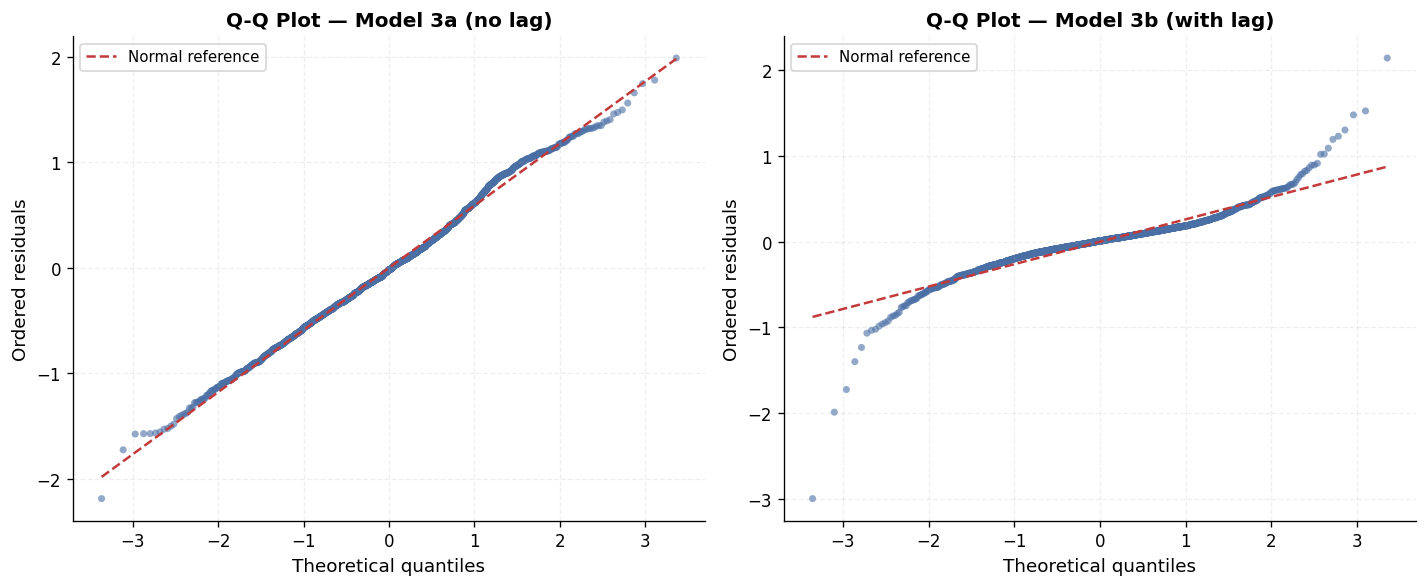

  ✓ Saved residual_qq.png

Breusch-Pagan test (H0: homoskedastic):
  Model 3a: LM=120.720  p=0.0000  → reject H0 — heteroskedastic
  Model 3b: LM=84.559  p=0.0000  → reject H0 — heteroskedastic
  (Clustered SEs remain valid regardless of this result)


In [11]:
# ── Residual diagnostics — Models 3a / 3b ────────────────────────────────────
# Durbin-Watson is reported in the summary but does not diagnose
# heteroskedasticity or non-normality. Added:
#   1. QQ plot of residuals (visual normality check)
#   2. Breusch-Pagan test (formal heteroskedasticity test)
# Note: clustered SEs are robust to heteroskedasticity within clusters,
# so finding heteroskedasticity does not invalidate the inference — but
# reporting these diagnostics strengthens econometric credibility.
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, m_raw, label in [
    (axes[0], m3a_raw, 'Model 3a (no lag)'),
    (axes[1], m3b_raw, 'Model 3b (with lag)'),
]:
    resid = m_raw.resid
    (osm, osr), (slope, intercept, _) = stats.probplot(resid, dist='norm')
    ax.scatter(osm, osr, s=18, alpha=0.6, color=PALETTE['blue'], edgecolor='none')
    ax.plot(
        [osm[0], osm[-1]],
        [osm[0] * slope + intercept, osm[-1] * slope + intercept],
        color=PALETTE['red'], linewidth=1.5, linestyle='--', label='Normal reference'
    )
    ax.set_xlabel('Theoretical quantiles', fontsize=11)
    ax.set_ylabel('Ordered residuals', fontsize=11)
    ax.set_title(f'Q-Q Plot — {label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'residual_qq.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('  ✓ Saved residual_qq.png')

# ── Breusch-Pagan test ────────────────────────────────────────────────────────
print('\nBreusch-Pagan test (H0: homoskedastic):')
for m_raw, X_reg, label in [
    (m3a_raw, X3a, 'Model 3a'),
    (m3b_raw, X3b, 'Model 3b'),
]:
    lm_stat, lm_pval, _, _ = het_breuschpagan(m_raw.resid, X_reg)
    verdict = 'reject H0 — heteroskedastic' if lm_pval < 0.05 else 'fail to reject H0'
    print(f'  {label}: LM={lm_stat:.3f}  p={lm_pval:.4f}  → {verdict}')
print('  (Clustered SEs remain valid regardless of this result)')


## A.2  Variance Inflation Factor (VIF)

VIF quantifies how much the variance of a coefficient estimate is inflated by multicollinearity with other regressors. Computed on the uncentred design matrix of **Model 3a** (parsimonious, no lag) and **Model 3b** (with ECI_lag1). Rule of thumb: VIF < 5 = acceptable, 5–10 = moderate, > 10 = problematic. Interaction terms are mean-centred before multiplication (same as in the models), which substantially reduces their VIF relative to uncentred products.

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display, HTML

def compute_vif(X_df):
    """Return a DataFrame with VIF for each column of X_df (must include const)."""
    vif = pd.DataFrame()
    vif['Variable'] = X_df.columns
    vif['VIF'] = [variance_inflation_factor(X_df.values, i)
                  for i in range(X_df.shape[1])]
    vif = vif[vif['Variable'] != 'const'].sort_values('VIF', ascending=False).reset_index(drop=True)
    vif['Flag'] = vif['VIF'].apply(lambda v: '⚠️  high' if v > 10 else ('🟡  moderate' if v > 5 else '✅  ok'))
    return vif

# ── Model 3a (no lag) ────────────────────────────────────────────────────────
X3a_vif = sm.add_constant(
    reg3_df[reg3_input + INTERACT_VARS].copy()
).dropna()
vif_3a = compute_vif(X3a_vif)

# ── Model 3b (with ECI_lag1) ─────────────────────────────────────────────────
X3b_vif = sm.add_constant(
    reg3b_df[reg3_input + ['ECI_lag1'] + INTERACT_VARS].copy()
).dropna()
vif_3b = compute_vif(X3b_vif)

# ── Pretty-print side by side ─────────────────────────────────────────────────
vif_both = vif_3a.rename(columns={'VIF':'VIF (3a)','Flag':'Flag (3a)'})\
    .merge(vif_3b.rename(columns={'VIF':'VIF (3b)','Flag':'Flag (3b)'}),
           on='Variable', how='outer').sort_values('VIF (3a)', ascending=False)

# ── Console output ────────────────────────────────────────────────────────────
print('=' * 68)
print(f"  {'Variable':<42} {'VIF 3a':>7} {'VIF 3b':>7}")
print('=' * 68)
for _, row in vif_both.iterrows():
    v3a = f"{row['VIF (3a)']:.2f}" if pd.notna(row.get('VIF (3a)')) else '  n/a'
    v3b = f"{row['VIF (3b)']:.2f}" if pd.notna(row.get('VIF (3b)')) else '  n/a'
    flag = row.get('Flag (3a)','')  
    print(f"  {str(row['Variable']):<42} {v3a:>7} {v3b:>7}   {flag}")
print('=' * 68)

# ── HTML export ───────────────────────────────────────────────────────────────
def _flag_color(v):
    if pd.isna(v): return ''
    return 'color:#b91c1c;font-weight:bold' if v > 10 else ('color:#d97706' if v > 5 else 'color:#15803d')

rows_html = ''
for _, row in vif_both.iterrows():
    v3a = row.get('VIF (3a)')
    v3b = row.get('VIF (3b)')
    c3a = _flag_color(v3a)
    c3b = _flag_color(v3b)
    s3a = f'<span style="{c3a}">{v3a:.2f}</span>' if pd.notna(v3a) else '<span style="color:#aaa">n/a</span>'
    s3b = f'<span style="{c3b}">{v3b:.2f}</span>' if pd.notna(v3b) else '<span style="color:#aaa">n/a</span>'
    rows_html += f'<tr><td style="text-align:left;padding:3px 12px">{row["Variable"]}</td><td>{s3a}</td><td>{s3b}</td></tr>\n'

vif_html = f"""
<!DOCTYPE html><html lang="en"><head><meta charset="UTF-8">
<style>
  body  {{ font-family:'Times New Roman',serif; font-size:13px; margin:40px; }}
  h2    {{ font-size:14px; font-weight:normal; text-align:center; margin-bottom:4px; }}
  table {{ border-collapse:collapse; width:420px; margin:0 auto; }}
  th,td {{ padding:3px 12px; text-align:center; }}
  .top  {{ border-top:2px solid #000; }}
  .mid  {{ border-top:1px solid #000; }}
  .bot  {{ border-bottom:2px solid #000; }}
  .note {{ font-size:11px; width:420px; margin:6px auto 0; }}
</style></head><body>
<h2>Variance Inflation Factors — Models 3a and 3b</h2>
<table>
  <thead>
    <tr class="top mid"><th style="text-align:left">Variable</th><th>VIF (3a)</th><th>VIF (3b)</th></tr>
  </thead>
  <tbody class="bot">
    {{rows_html}}
  </tbody>
</table>
<p class="note"><em>Note:</em> Green = VIF &lt; 5 (acceptable); amber = 5–10 (moderate); red = &gt;10 (high). 
Interaction terms are mean-centred before multiplication. Model 3b includes ECI_lag1 as an additional regressor.</p>
</body></html>"""

vif_path = os.path.join(OUT, 'vif_table.html')
with open(vif_path, 'w', encoding='utf-8') as _f:
    _f.write(vif_html)
print(f'\n✓ Saved {vif_path}')


# ── VIF bar chart ────────────────────────────────────────────────────────────
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

_vars_sorted = vif_both.sort_values('VIF (3a)', ascending=True)['Variable'].tolist()
_v3a = [vif_3a.get(v, float('nan')) for v in _vars_sorted]
_v3b = [vif_3b.get(v, float('nan')) for v in _vars_sorted]

_NAVY='#1a2744'; _BLUE='#4a6fa5'; _LIGHT='#8fb0d4'; _AMB='#d97706'; _RED='#b91c1c'
fig, ax = plt.subplots(figsize=(9, 5.5)); fig.patch.set_facecolor('white'); ax.set_facecolor('white')
_n=len(_vars_sorted); _y=range(_n); _h=0.35
for i,(val,var) in enumerate(zip(_v3b,_vars_sorted)):
    if val==val: ax.barh(i-_h/2,val,_h,color=_LIGHT,alpha=0.9,zorder=3); ax.text(val+0.04,i-_h/2,f'{val:.2f}',va='center',fontsize=8,color=_NAVY)
for i,(val,var) in enumerate(zip(_v3a,_vars_sorted)):
    if val==val: ax.barh(i+_h/2,val,_h,color=_BLUE,alpha=0.9,zorder=3); ax.text(val+0.04,i+_h/2,f'{val:.2f}',va='center',fontsize=8,color=_NAVY)
ax.axvline(5,color=_AMB,linestyle='--',linewidth=1.2,zorder=4)
ax.axvline(10,color=_RED,linestyle='--',linewidth=1.2,zorder=4)
ax.set_yticks(list(_y)); ax.set_yticklabels(_vars_sorted,fontsize=9.5)
ax.set_xlabel('Variance Inflation Factor (VIF)',fontsize=10.5,color=_NAVY)
ax.set_title('Variance Inflation Factors — Models 3a and 3b\nAll VIFs well below 5: no multicollinearity concern',fontsize=11,color=_NAVY,pad=10)
ax.set_xlim(0,6.5); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.xaxis.grid(True,color='#e5e7eb',linewidth=0.6,zorder=0); ax.set_axisbelow(True)
ax.legend(handles=[
    mpatches.Patch(color=_BLUE,label='Model 3a (no lag)'),
    mpatches.Patch(color=_LIGHT,label='Model 3b (ECI lag)'),
    plt.Line2D([],[],color=_AMB,linestyle='--',label='VIF = 5'),
    plt.Line2D([],[],color=_RED,linestyle='--',label='VIF = 10'),
],fontsize=9,framealpha=0,loc='lower right')
plt.tight_layout(pad=1.8)
_vif_chart = os.path.join(OUT,'vif_chart.png')
plt.savefig(_vif_chart,dpi=180,bbox_inches='tight',facecolor='white'); plt.show()
print(f'✓ Saved {_vif_chart}')


  Variable                                    VIF 3a  VIF 3b
  log_HCI_x_forestry_rents                      3.39    3.20   ✅  ok
  Forestry rents (% of GDP)                     3.13    3.13   ✅  ok
  log_GFCF_x_forestry_rents                     2.03    1.97   ✅  ok
  log_Production_Value                          1.95    2.02   ✅  ok
  log_HCI                                       1.86    2.10   ✅  ok
  log_HCI_x_log_Production                      1.79    1.77   ✅  ok
  Political stability — estimate                1.65    1.65   ✅  ok
  log_GFCF_x_log_Production                     1.64    1.64   ✅  ok
  Trade (% of GDP)                              1.44    1.45   ✅  ok
  Rule of law index                             1.41    1.47   ✅  ok
  log_GFCF                                      1.23    1.24   ✅  ok
  ECI_lag1                                       n/a    1.50   nan

✓ Saved Graphics/NB6/vif_table.html


✓ Saved Graphics/NB6/vif_chart.png


## 5b. Model 3c — All Regressors Lagged One Period

All 7 parsimonious regressors and their interaction terms are lagged one period (t−1). ECI_lag1 is included. This specification addresses endogeneity: all RHS variables are predetermined at t−1 relative to the outcome at t.

In [13]:
# == Model 3c: all 7 parsimonious vars lagged + ECI_lag1 + lagged interactions ====
_vars_3c = [
    'log_HCI', 'log_GFCF',
    'Political stability — estimate', 'Rule of law index',
    'log_Production_Value', 'Forestry rents (% of GDP)', 'Trade (% of GDP)',
]

reg3c_df = df[_vars_3c + ['Economic Complexity Index', 'Country Code', 'Year']].copy()
for v in _vars_3c:
    reg3c_df[v] = pd.to_numeric(reg3c_df[v], errors='coerce')
reg3c_df = reg3c_df.dropna().sort_values(['Country Code', 'Year'])

# Lag all regressors and ECI
for v in _vars_3c:
    reg3c_df[f'{v}_lag1'] = reg3c_df.groupby('Country Code')[v].shift(1)
reg3c_df['ECI_lag1'] = reg3c_df.groupby('Country Code')['Economic Complexity Index'].shift(1)
_lag_names_3c = [f'{v}_lag1' for v in _vars_3c]
reg3c_df = reg3c_df.dropna(subset=_lag_names_3c + ['ECI_lag1'])

# Centre the lagged log variables for interactions
reg3c_df['_hci_c']  = reg3c_df['log_HCI_lag1']              - reg3c_df['log_HCI_lag1'].mean()
reg3c_df['_gfcf_c'] = reg3c_df['log_GFCF_lag1']             - reg3c_df['log_GFCF_lag1'].mean()
reg3c_df['_prod_c'] = reg3c_df['log_Production_Value_lag1']  - reg3c_df['log_Production_Value_lag1'].mean()
reg3c_df['_frt_c']  = reg3c_df['Forestry rents (% of GDP)_lag1'] - reg3c_df['Forestry rents (% of GDP)_lag1'].mean()

reg3c_df['log_HCI_x_log_Production_lag1']  = reg3c_df['_hci_c']  * reg3c_df['_prod_c']
reg3c_df['log_GFCF_x_log_Production_lag1'] = reg3c_df['_gfcf_c'] * reg3c_df['_prod_c']
reg3c_df['log_HCI_x_forestry_rents_lag1']  = reg3c_df['_hci_c']  * reg3c_df['_frt_c']
reg3c_df['log_GFCF_x_forestry_rents_lag1'] = reg3c_df['_gfcf_c'] * reg3c_df['_frt_c']

_interact_3c = [
    'log_HCI_x_log_Production_lag1', 'log_GFCF_x_log_Production_lag1',
    'log_HCI_x_forestry_rents_lag1', 'log_GFCF_x_forestry_rents_lag1',
]

y3c = reg3c_df['Economic Complexity Index']
X3c = sm.add_constant(reg3c_df[_lag_names_3c + ['ECI_lag1'] + _interact_3c])

m3c, m3c_raw = fit_clustered(
    y3c, X3c, reg3c_df['Country Code'],
    label='MODEL 3c -- All Regressors Lagged (Clustered SE by Country)')



MODEL 3c -- All Regressors Lagged (Clustered SE by Country)
  N obs:        1,736
  N countries:  74
  R²:           0.8543
  Adj. R²:      0.8533
  Durbin-Watson: 2.635

  Variable                                         Coef        SE       t       p
  ----------------------------------------------------------------------------
  const                                         -0.2738    0.1107   -2.47  0.0157 **
  log_HCI_lag1                                   0.1479    0.0725    2.04  0.0449 **
  log_GFCF_lag1                                  0.0181    0.0118    1.53  0.1303 
  Political stability — estimate_lag1            0.0081    0.0106    0.77  0.4459 
  Rule of law index_lag1                         0.0617    0.0415    1.49  0.1415 
  log_Production_Value_lag1                     -0.0060    0.0041   -1.47  0.1449 
  Forestry rents (% of GDP)_lag1                -0.0062    0.0026   -2.37  0.0202 **
  Trade (% of GDP)_lag1                          0.0002    0.0003    0.74  0.464

## 5c. Models 4a / 4b — Extra Controls (Resource-Type Dummies + Electricity)

Adds `Hydrocarbons_Dominant`, `Subsoil_Metals_Dominant`, `Precious_Metals_Dominant`, and `Access to electricity` to the parsimonious set. Model 4a uses contemporaneous regressors + ECI_lag1; Model 4b lags all regressors.

In [14]:
# == Model 4a: contemporaneous extra controls + ECI_lag1 ======================
_vars_4 = [
    'log_HCI', 'log_GFCF',
    'Political stability — estimate', 'Rule of law index',
    'log_Production_Value', 'Forestry rents (% of GDP)', 'Trade (% of GDP)',
    'Hydrocarbons_Dominant', 'Subsoil_Metals_Dominant', 'Precious_Metals_Dominant',
    'Access to electricity (% of population)',
]

reg4a_df = df[_vars_4 + ['Economic Complexity Index', 'Country Code', 'Year']].copy()
for v in _vars_4:
    reg4a_df[v] = pd.to_numeric(reg4a_df[v], errors='coerce')
reg4a_df = reg4a_df.dropna().sort_values(['Country Code', 'Year'])
reg4a_df['ECI_lag1'] = reg4a_df.groupby('Country Code')['Economic Complexity Index'].shift(1)
reg4a_df = reg4a_df.dropna(subset=['ECI_lag1'])

# Centre log vars for interactions
reg4a_df['_hci_c']  = reg4a_df['log_HCI']              - reg4a_df['log_HCI'].mean()
reg4a_df['_gfcf_c'] = reg4a_df['log_GFCF']             - reg4a_df['log_GFCF'].mean()
reg4a_df['_prod_c'] = reg4a_df['log_Production_Value']  - reg4a_df['log_Production_Value'].mean()
reg4a_df['_frt_c']  = reg4a_df['Forestry rents (% of GDP)'] - reg4a_df['Forestry rents (% of GDP)'].mean()

reg4a_df['log_HCI_x_log_Production']  = reg4a_df['_hci_c']  * reg4a_df['_prod_c']
reg4a_df['log_GFCF_x_log_Production'] = reg4a_df['_gfcf_c'] * reg4a_df['_prod_c']
reg4a_df['log_HCI_x_forestry_rents']  = reg4a_df['_hci_c']  * reg4a_df['_frt_c']
reg4a_df['log_GFCF_x_forestry_rents'] = reg4a_df['_gfcf_c'] * reg4a_df['_frt_c']

_interact_4 = [
    'log_HCI_x_log_Production', 'log_GFCF_x_log_Production',
    'log_HCI_x_forestry_rents', 'log_GFCF_x_forestry_rents',
]

y4a = reg4a_df['Economic Complexity Index']
X4a = sm.add_constant(reg4a_df[_vars_4 + ['ECI_lag1'] + _interact_4])

m4a, m4a_raw = fit_clustered(
    y4a, X4a, reg4a_df['Country Code'],
    label='MODEL 4a -- Extra Controls + ECI lag (Clustered SE by Country)')

# == Model 4b: all regressors lagged + extra controls =========================
reg4b_df = df[_vars_4 + ['Economic Complexity Index', 'Country Code', 'Year']].copy()
for v in _vars_4:
    reg4b_df[v] = pd.to_numeric(reg4b_df[v], errors='coerce')
reg4b_df = reg4b_df.dropna().sort_values(['Country Code', 'Year'])

for v in _vars_4:
    reg4b_df[f'{v}_lag1'] = reg4b_df.groupby('Country Code')[v].shift(1)
reg4b_df['ECI_lag1'] = reg4b_df.groupby('Country Code')['Economic Complexity Index'].shift(1)
_lag_names_4b = [f'{v}_lag1' for v in _vars_4]
reg4b_df = reg4b_df.dropna(subset=_lag_names_4b + ['ECI_lag1'])

reg4b_df['_hci_c']  = reg4b_df['log_HCI_lag1']              - reg4b_df['log_HCI_lag1'].mean()
reg4b_df['_gfcf_c'] = reg4b_df['log_GFCF_lag1']             - reg4b_df['log_GFCF_lag1'].mean()
reg4b_df['_prod_c'] = reg4b_df['log_Production_Value_lag1']  - reg4b_df['log_Production_Value_lag1'].mean()
reg4b_df['_frt_c']  = reg4b_df['Forestry rents (% of GDP)_lag1'] - reg4b_df['Forestry rents (% of GDP)_lag1'].mean()

reg4b_df['log_HCI_x_log_Production_lag1']  = reg4b_df['_hci_c']  * reg4b_df['_prod_c']
reg4b_df['log_GFCF_x_log_Production_lag1'] = reg4b_df['_gfcf_c'] * reg4b_df['_prod_c']
reg4b_df['log_HCI_x_forestry_rents_lag1']  = reg4b_df['_hci_c']  * reg4b_df['_frt_c']
reg4b_df['log_GFCF_x_forestry_rents_lag1'] = reg4b_df['_gfcf_c'] * reg4b_df['_frt_c']

_interact_4b = [
    'log_HCI_x_log_Production_lag1', 'log_GFCF_x_log_Production_lag1',
    'log_HCI_x_forestry_rents_lag1', 'log_GFCF_x_forestry_rents_lag1',
]

y4b = reg4b_df['Economic Complexity Index']
X4b = sm.add_constant(reg4b_df[_lag_names_4b + ['ECI_lag1'] + _interact_4b])

m4b, m4b_raw = fit_clustered(
    y4b, X4b, reg4b_df['Country Code'],
    label='MODEL 4b -- All Lagged + Extra Controls (Clustered SE by Country)')



MODEL 4a -- Extra Controls + ECI lag (Clustered SE by Country)
  N obs:        1,712
  N countries:  74
  R²:           0.8596
  Adj. R²:      0.8583
  Durbin-Watson: 2.587

  Variable                                         Coef        SE       t       p
  ----------------------------------------------------------------------------
  const                                         -0.3264    0.0985   -3.31  0.0014 ***
  log_HCI                                        0.0634    0.0648    0.98  0.3309 
  log_GFCF                                       0.0195    0.0111    1.75  0.0841 *
  Political stability — estimate                 0.0183    0.0164    1.11  0.2698 
  Rule of law index                              0.0947    0.0424    2.23  0.0288 **
  log_Production_Value                          -0.0184    0.0069   -2.69  0.0089 ***
  Forestry rents (% of GDP)                      0.0031    0.0035    0.89  0.3761 
  Trade (% of GDP)                               0.0001    0.0003    0.37 

## 5d. Models 5 & 6 — AR (log ECI) and First-Difference (ΔECI)

**Model 5**: AR baseline on log-transformed ECI — log(ECI_shifted) ~ log(ECI_shifted)_{t-1}. Provides a log-scale persistence benchmark.

**Model 6**: First-difference specification — ΔECI = ECI_t − ECI_{t-1} as dependent variable. ECI_{t-1} enters as an error-correction term. Extra controls included.

In [15]:
# == Model 5: log_ECI AR baseline ============================================
reg5_df = df[['log_ECI', 'log_ECI_lag1', 'Country Code', 'Year']].dropna()

y5  = reg5_df['log_ECI']
X5  = sm.add_constant(reg5_df[['log_ECI_lag1']])
m5, m5_raw = fit_clustered(
    y5, X5, reg5_df['Country Code'],
    label='MODEL 5 -- AR Baseline: log(ECI) ~ log(ECI)_lag1 (Clustered SE by Country)')

# == Model 6: ΔECI (first difference) as dependent variable ==================
_vars_6 = [
    'log_HCI', 'log_GFCF',
    'Political stability — estimate', 'Rule of law index',
    'log_Production_Value', 'Trade (% of GDP)', 'Forestry rents (% of GDP)',
    'Hydrocarbons_Dominant', 'Subsoil_Metals_Dominant', 'Precious_Metals_Dominant',
    'Access to electricity (% of population)',
]

reg6_df = df[_vars_6 + ['Economic Complexity Index', 'Country Code', 'Year']].copy()
for v in _vars_6:
    reg6_df[v] = pd.to_numeric(reg6_df[v], errors='coerce')
reg6_df = reg6_df.dropna().sort_values(['Country Code', 'Year'])
reg6_df['ECI_lag1']  = reg6_df.groupby('Country Code')['Economic Complexity Index'].shift(1)
reg6_df['delta_ECI'] = reg6_df['Economic Complexity Index'] - reg6_df['ECI_lag1']
reg6_df = reg6_df.dropna(subset=['ECI_lag1', 'delta_ECI'])

# Centre log vars for interactions
reg6_df['_hci_c']  = reg6_df['log_HCI']              - reg6_df['log_HCI'].mean()
reg6_df['_gfcf_c'] = reg6_df['log_GFCF']             - reg6_df['log_GFCF'].mean()
reg6_df['_prod_c'] = reg6_df['log_Production_Value']  - reg6_df['log_Production_Value'].mean()
reg6_df['_frt_c']  = reg6_df['Forestry rents (% of GDP)'] - reg6_df['Forestry rents (% of GDP)'].mean()

reg6_df['log_HCI_x_log_Production']  = reg6_df['_hci_c']  * reg6_df['_prod_c']
reg6_df['log_GFCF_x_log_Production'] = reg6_df['_gfcf_c'] * reg6_df['_prod_c']
reg6_df['log_HCI_x_forestry_rents']  = reg6_df['_hci_c']  * reg6_df['_frt_c']
reg6_df['log_GFCF_x_forestry_rents'] = reg6_df['_gfcf_c'] * reg6_df['_frt_c']

_interact_6 = [
    'log_HCI_x_log_Production', 'log_GFCF_x_log_Production',
    'log_HCI_x_forestry_rents', 'log_GFCF_x_forestry_rents',
]

y6  = reg6_df['delta_ECI']
X6  = sm.add_constant(reg6_df[_vars_6 + ['ECI_lag1'] + _interact_6])

m6, m6_raw = fit_clustered(
    y6, X6, reg6_df['Country Code'],
    label='MODEL 6 -- First-Difference DV: ΔECI (Clustered SE by Country)')



MODEL 5 -- AR Baseline: log(ECI) ~ log(ECI)_lag1 (Clustered SE by Country)
  N obs:        1,800
  N countries:  75
  R²:           0.7811
  Adj. R²:      0.7810
  Durbin-Watson: 2.651

  Variable                                         Coef        SE       t       p
  ----------------------------------------------------------------------------
  const                                          0.1370    0.0298    4.59  0.0000 ***
  log_ECI_lag1                                   0.8834    0.0268   32.95  0.0000 ***

MODEL 6 -- First-Difference DV: ΔECI (Clustered SE by Country)
  N obs:        1,712
  N countries:  74
  R²:           0.0779
  Adj. R²:      0.0692
  Durbin-Watson: 2.587

  Variable                                         Coef        SE       t       p
  ----------------------------------------------------------------------------
  const                                         -0.3264    0.0985   -3.31  0.0014 ***
  log_HCI                                        0.0634   

## 5e. Export: HTML Regression Tables

Two publication-style HTML tables:
- **Table A**: Models 3a / 3b / 3c (parsimonious: no lag, with ECI lag, all lagged)
- **Table B** (Appendix): Models 4a / 4b (extra controls)

In [16]:
# ── Shared helpers ────────────────────────────────────────────────────────────
def _stars(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

def _fmt(res, candidates):
    for v in (candidates or []):
        if v and v in res.params.index:
            c, s, p = res.params[v], res.bse[v], res.pvalues[v]
            return f'{c:.3f}{_stars(p)}', f'({s:.3f})'
    return '', ''

def _html_table(var_map, section_before, models, obs_list, country_list,
                r2_list, adj_r2_list, col_headers, title):
    n = len(models)
    w = 560 + (n - 1) * 80
    rows = ''
    for label, name_variants in var_map:
        cells_c, cells_s = [], []
        found = False
        for i, res in enumerate(models):
            cands = [name_variants[i]] if i < len(name_variants) and name_variants[i] else []
            c, s = _fmt(res, cands)
            if c: found = True
            cells_c.append(c); cells_s.append(s)
        if not found: continue
        if label in section_before:
            sec = section_before[label]
            rows += f'<tr class="section-lbl mid-border"><td colspan="{n+1}">{sec}</td></tr>\n'
        rows += '<tr><td class="varname">' + label + '</td>' + ''.join(f'<td>{c}</td>' for c in cells_c) + '</tr>\n'
        rows += '<tr class="se-row"><td></td>' + ''.join(f'<td>{s}</td>' for s in cells_s) + '</tr>\n'
    hths = ''.join(f'<th>{h}</th>' for h in col_headers)
    obs_r  = ''.join(f'<td>{o:,}</td>' for o in obs_list)
    cty_r  = ''.join(f'<td>{c}</td>'   for c in country_list)
    r2_r   = ''.join(f'<td>{r:.3f}</td>' for r in r2_list)
    ar2_r  = ''.join(f'<td>{r:.3f}</td>' for r in adj_r2_list)
    return f'''<!DOCTYPE html><html lang="en"><head><meta charset="UTF-8">
<style>
  body  {{ font-family: "Times New Roman", Times, serif; font-size:13px; margin:40px; color:#000; }}
  h2    {{ font-size:14px; font-weight:normal; text-align:center; margin-bottom:4px; }}
  table {{ border-collapse:collapse; width:{w}px; margin:0 auto; }}
  th,td {{ padding:3px 10px; text-align:center; }}
  td.varname {{ text-align:left; padding-left:4px; min-width:240px; }}
  tr.se-row td {{ padding-top:0; padding-bottom:4px; }}
  .top-border {{ border-top:2px solid #000; }}
  .mid-border {{ border-top:1px solid #000; }}
  .bot-border {{ border-bottom:2px solid #000; }}
  .section-lbl td {{ font-style:italic; font-size:11px; padding-top:6px; color:#444; text-align:left; }}
  .note {{ font-size:11px; text-align:left; width:{w}px; margin:4px auto 0; }}
  sup {{ font-size:9px; }}
</style></head><body>
<h2>{title}</h2><table>
<thead>
  <tr class="top-border"><th></th><th colspan="{n}"><em>Dependent variable: Economic Complexity Index</em></th></tr>
  <tr class="mid-border bot-border"><th></th>{hths}</tr>
</thead><tbody>
{rows}
<tr class="mid-border"><td class="varname">Observations</td>{obs_r}</tr>
<tr><td class="varname">Countries</td>{cty_r}</tr>
<tr><td class="varname">R<sup>2</sup></td>{r2_r}</tr>
<tr><td class="varname">Adjusted R<sup>2</sup></td>{ar2_r}</tr>
<tr class="bot-border"><td class="varname">Clustered SE</td><td colspan="{n}">Country</td></tr>
</tbody></table>
<p class="note"><em>Note:</em>&nbsp;<sup>*</sup>p&lt;0.1;&nbsp;<sup>**</sup>p&lt;0.05;&nbsp;<sup>***</sup>p&lt;0.01. Clustered SEs by country in parentheses.</p>
</body></html>'''

# ── Table A: Models 3a / 3b / 3c ─────────────────────────────────────────────
VARS_A = [
    ('Human Capital Index (log)',              ['log_HCI',              'log_HCI',              'log_HCI_lag1']),
    ('Gross Fixed Capital Formation (log)',    ['log_GFCF',             'log_GFCF',             'log_GFCF_lag1']),
    ('Production Value (log)',                 ['log_Production_Value', 'log_Production_Value', 'log_Production_Value_lag1']),
    ('Political Stability',                    ['Political stability — estimate', 'Political stability — estimate', 'Political stability — estimate_lag1']),
    ('Rule of Law',                            ['Rule of law index',    'Rule of law index',    'Rule of law index_lag1']),
    ('Trade Openness (% of GDP)',              ['Trade (% of GDP)',     'Trade (% of GDP)',     'Trade (% of GDP)_lag1']),
    ('Forestry Rents (% of GDP)',              ['Forestry rents (% of GDP)', 'Forestry rents (% of GDP)', 'Forestry rents (% of GDP)_lag1']),
    ('HCI × Production (log)',                ['log_HCI_x_log_Production',  'log_HCI_x_log_Production',  'log_HCI_x_log_Production_lag1']),
    ('GFCF × Production (log)',               ['log_GFCF_x_log_Production', 'log_GFCF_x_log_Production', 'log_GFCF_x_log_Production_lag1']),
    ('HCI × Forestry Rents',                  ['log_HCI_x_forestry_rents',  'log_HCI_x_forestry_rents',  'log_HCI_x_forestry_rents_lag1']),
    ('GFCF × Forestry Rents',                 ['log_GFCF_x_forestry_rents', 'log_GFCF_x_forestry_rents', 'log_GFCF_x_forestry_rents_lag1']),
    ('Economic Complexity Index (t−1)',        [None,                   'ECI_lag1',             'ECI_lag1']),
    ('Constant',                               ['const',               'const',                'const']),
]
SEC_A = {
    'HCI × Production (log)':         'Interaction terms',
    'Economic Complexity Index (t−1)': 'Lagged dependent variable',
}

html_a = _html_table(
    var_map      = VARS_A,
    section_before = SEC_A,
    models       = [m3a, m3b, m3c],
    obs_list     = [int(m3a.nobs), int(m3b.nobs), int(m3c.nobs)],
    country_list = [reg3_df['Country Code'].nunique(), reg3b_df['Country Code'].nunique(), reg3c_df['Country Code'].nunique()],
    r2_list      = [m3a.rsquared, m3b.rsquared, m3c.rsquared],
    adj_r2_list  = [m3a.rsquared_adj, m3b.rsquared_adj, m3c.rsquared_adj],
    col_headers  = ['(1) No lag', '(2) ECI lag', '(3) All lagged'],
    title        = 'Economic Complexity in Resource-Rich Countries',
)
with open(os.path.join(OUT, 'regression_table_main.html'), 'w', encoding='utf-8') as _f:
    _f.write(html_a)
print('✓ Saved Graphics/NB6/regression_table_main.html')

# ── Table B: Models 4a / 4b (Appendix) ───────────────────────────────────────
VARS_B = [
    ('Human Capital Index (log)',              ['log_HCI',              'log_HCI_lag1']),
    ('Gross Fixed Capital Formation (log)',    ['log_GFCF',             'log_GFCF_lag1']),
    ('Production Value (log)',                 ['log_Production_Value', 'log_Production_Value_lag1']),
    ('Political Stability',                    ['Political stability — estimate', 'Political stability — estimate_lag1']),
    ('Rule of Law',                            ['Rule of law index',    'Rule of law index_lag1']),
    ('Trade Openness (% of GDP)',              ['Trade (% of GDP)',     'Trade (% of GDP)_lag1']),
    ('Forestry Rents (% of GDP)',              ['Forestry rents (% of GDP)', 'Forestry rents (% of GDP)_lag1']),
    ('Hydrocarbons Dominant',                  ['Hydrocarbons_Dominant', 'Hydrocarbons_Dominant_lag1']),
    ('Subsoil Metals Dominant',               ['Subsoil_Metals_Dominant', 'Subsoil_Metals_Dominant_lag1']),
    ('Precious Metals Dominant',              ['Precious_Metals_Dominant', 'Precious_Metals_Dominant_lag1']),
    ('Access to Electricity (%)',             ['Access to electricity (% of population)', 'Access to electricity (% of population)_lag1']),
    ('HCI × Production (log)',                ['log_HCI_x_log_Production',  'log_HCI_x_log_Production_lag1']),
    ('GFCF × Production (log)',               ['log_GFCF_x_log_Production', 'log_GFCF_x_log_Production_lag1']),
    ('HCI × Forestry Rents',                  ['log_HCI_x_forestry_rents',  'log_HCI_x_forestry_rents_lag1']),
    ('GFCF × Forestry Rents',                 ['log_GFCF_x_forestry_rents', 'log_GFCF_x_forestry_rents_lag1']),
    ('Economic Complexity Index (t−1)',        ['ECI_lag1',             'ECI_lag1']),
    ('Constant',                               ['const',                'const']),
]
SEC_B = {
    'HCI × Production (log)':         'Interaction terms',
    'Economic Complexity Index (t−1)': 'Lagged dependent variable',
}

html_b = _html_table(
    var_map      = VARS_B,
    section_before = SEC_B,
    models       = [m4a, m4b],
    obs_list     = [int(m4a.nobs), int(m4b.nobs)],
    country_list = [reg4a_df['Country Code'].nunique(), reg4b_df['Country Code'].nunique()],
    r2_list      = [m4a.rsquared, m4b.rsquared],
    adj_r2_list  = [m4a.rsquared_adj, m4b.rsquared_adj],
    col_headers  = ['(4a) Extra controls', '(4b) All lagged + controls'],
    title        = 'Economic Complexity — Appendix: Extra Controls',
)
with open(os.path.join(OUT, 'regression_table_appendix.html'), 'w', encoding='utf-8') as _f:
    _f.write(html_b)
print('✓ Saved Graphics/NB6/regression_table_appendix.html')


✓ Saved Graphics/NB6/regression_table_main.html
✓ Saved Graphics/NB6/regression_table_appendix.html


## 6. Sample Comparison — 54 Resource-Rich vs All Countries

The 54-country sample was selected based on NR rents ≥ 5 % of GDP in 1995.
This section re-estimates Models 3a and 3b on the **full Master dataset** (all
available countries) and compares coefficients. The purpose is to assess whether
the interaction effects are specific to resource-dependent economies or hold more
broadly.

**Note on centring**: the mean-centring of interaction terms is computed separately
for each sample (using the respective grand mean), so interaction coefficients are
not directly comparable in magnitude across samples. They are comparable in sign
and significance.

In [17]:
# == Prepare the full-sample dataframe =============================================
df_all = master.copy()

if 'Unnamed: 0' in df_all.columns:
    df_all = df_all.drop(columns=['Unnamed: 0'])

df_all['Total_Production_Value_Per_Capita'] = df_all['Total_Production_Value'] / df_all['Population']

df_all['log_HCI']              = np.log(df_all['Human capital index'] + 1)
df_all['log_GFCF']             = np.log(df_all['Gross fixed capital formation, all, Constant prices, Percent of GDP'] + 1)
df_all['log_Production_Value'] = np.log(df_all['Total_Production_Value_Per_Capita'] + 1)

# Centre df_all on the 54-country sample means (not the full-sample mean).
# This ensures main-effect coefficients are evaluated at the same point as
# in Models 3a/3b, making the coefficient deltas in the comparison table
# directly interpretable as shifts in effect size, not shifts in evaluation point.
_centre_means = {col: df[col].mean()
                 for col in ['log_HCI', 'log_GFCF', 'log_Production_Value']}
_centre_means['Forestry rents (% of GDP)'] = df['Forestry rents (% of GDP)'].mean()

for col in ['log_HCI', 'log_GFCF', 'log_Production_Value']:
    df_all[f'{col}_c'] = df_all[col] - _centre_means[col]

df_all['forestry_rents_c'] = df_all['Forestry rents (% of GDP)'] - _centre_means['Forestry rents (% of GDP)']

df_all['log_HCI_x_log_Production']  = df_all['log_HCI_c']  * df_all['log_Production_Value_c']
df_all['log_GFCF_x_log_Production'] = df_all['log_GFCF_c'] * df_all['log_Production_Value_c']
df_all['log_HCI_x_forestry_rents']  = df_all['log_HCI_c']  * df_all['forestry_rents_c']
df_all['log_GFCF_x_forestry_rents'] = df_all['log_GFCF_c'] * df_all['forestry_rents_c']

df_all = df_all.sort_values(['Country Code', 'Year'])
df_all['ECI_lag1'] = df_all.groupby('Country Code')['Economic Complexity Index'].shift(1)

print(f'Full sample: {df_all["Country Code"].nunique()} countries, '
      f'{df_all["Year"].nunique()} years, {len(df_all):,} obs')


# == Model 3a (full sample) =======================================================
all_3a_cols = reg3_input + INTERACT_VARS + ['Economic Complexity Index', 'Country Code', 'Year']
all_3a_df   = df_all[all_3a_cols].dropna()

m3a_all, m3a_all_raw = fit_clustered(
    all_3a_df['Economic Complexity Index'],
    sm.add_constant(all_3a_df[reg3_input + INTERACT_VARS]),
    all_3a_df['Country Code'],
    label='FULL SAMPLE -- Model 3a (no lag)')

# == Model 3b (full sample) =======================================================
all_3b_cols = all_3a_cols + ['ECI_lag1']
all_3b_df   = df_all[all_3b_cols].dropna()

m3b_all, m3b_all_raw = fit_clustered(
    all_3b_df['Economic Complexity Index'],
    sm.add_constant(all_3b_df[reg3_input + INTERACT_VARS + ['ECI_lag1']]),
    all_3b_df['Country Code'],
    label='FULL SAMPLE -- Model 3b (with lag)')


# == Comparison table ==============================================================
def sig(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else '   '

core_vars = reg3_input + INTERACT_VARS + ['ECI_lag1']
var_labels = {
    'log_HCI':                       'log(HCI)',
    'log_GFCF':                      'log(GFCF)',
    'Political stability — estimate':'Pol. stability',
    'Rule of law index':             'Rule of law',
    'log_Production_Value':          'log(Prod. val. p.c.)',
    'Trade (% of GDP)':              'Trade (% GDP)',
    'Forestry rents (% of GDP)':     'Forestry rents (% GDP)',
    'log_HCI_x_log_Production':      'log(HCI) x log(Prod)',
    'log_GFCF_x_log_Production':     'log(GFCF) x log(Prod)',
    'log_HCI_x_forestry_rents':      'log(HCI) x Forestry',
    'log_GFCF_x_forestry_rents':     'log(GFCF) x Forestry',
    'ECI_lag1':                       'Lagged ECI',
}

pairs = [
    ('Model 3a',  m3a,     m3a_all),
    ('Model 3b',  m3b,     m3b_all),
]

print('\n' + '=' * 110)
print('SAMPLE COMPARISON: 54 Resource-Rich Countries vs All Countries')
print('=' * 110)

for spec_name, m_54, m_full in pairs:
    n54   = int(m_54.nobs)
    nfull = int(m_full.nobs)
    nc_full = df_all['Country Code'].nunique()
    print(f'\n{chr(9472) * 110}')
    print(f'  {spec_name:<14} |  54 countries (N={n54:,})           |  All countries (N={nfull:,}, {nc_full} ctries)')
    print(f'  {"":14} |  R2 = {m_54.rsquared:.4f}                    |  R2 = {m_full.rsquared:.4f}')
    print(f'  {"Variable":<22} | {"Coef":>9} {"SE":>9} {"":>4}  | {"Coef":>9} {"SE":>9} {"":>4}  | Delta coef')
    print(f'  {chr(9472) * 22}-|{chr(9472) * 27}-|{chr(9472) * 27}-|{chr(9472) * 9}')
    for v in core_vars:
        label = var_labels.get(v, v[:22])
        c54  = m_54.params.get(v, None)
        c_all = m_full.params.get(v, None)
        if c54 is None and c_all is None:
            continue
        if c54 is not None:
            se54 = m_54.bse[v]
            s54  = sig(m_54.pvalues[v])
            c54_str = f'{c54:>+9.4f} {se54:>9.4f} {s54}'
        else:
            c54_str = f'{"":>24}'
            c54 = 0
        if c_all is not None:
            se_all = m_full.bse[v]
            s_all  = sig(m_full.pvalues[v])
            c_all_str = f'{c_all:>+9.4f} {se_all:>9.4f} {s_all}'
        else:
            c_all_str = f'{"":>24}'
            c_all = 0
        delta = c_all - c54 if (m_54.params.get(v) is not None and m_full.params.get(v) is not None) else None
        delta_str = f'{delta:>+9.4f}' if delta is not None else ''
        print(f'  {label:<22} | {c54_str} | {c_all_str} | {delta_str}')

print(f'\n{"=" * 110}')
print('Note: All countries = full Master.csv without the NR rents >= 5% filter.')
print('Interaction terms use grand-mean centring computed separately for each sample.')


Full sample: 75 countries, 25 years, 1,875 obs

FULL SAMPLE -- Model 3a (no lag)
  N obs:        1,810
  N countries:  74
  R²:           0.3370
  Adj. R²:      0.3329
  Durbin-Watson: 0.324

  Variable                                         Coef        SE       t       p
  ----------------------------------------------------------------------------
  const                                         -2.6176    0.5453   -4.80  0.0000 ***
  log_HCI                                        1.7422    0.3517    4.95  0.0000 ***
  log_GFCF                                       0.0790    0.0878    0.90  0.3713 
  Political stability — estimate                 0.0095    0.0753    0.13  0.9000 
  Rule of law index                              0.5600    0.2813    1.99  0.0503 *
  log_Production_Value                          -0.0589    0.0278   -2.12  0.0375 **
  Forestry rents (% of GDP)                     -0.0508    0.0184   -2.76  0.0073 ***
  Trade (% of GDP)                               0.000

## 7. Visualisations

### 7a. Coefficient Comparison — Model 3a vs 3b

Horizontal dot-and-whisker plot comparing point estimates and 95 % confidence
intervals for the core variables across the two specifications. If a variable's
confidence interval crosses zero, its association with ECI is not statistically
significant at the 5 % level.

In [18]:
plot_vars = [v for v in reg3_input + INTERACT_VARS if v != 'const']

labels = [v.replace('log_', 'log(').replace('_x_', ') × log(') + (')' if 'log_' in v else '')
          for v in plot_vars]

models_to_plot = [
    (m3a,  PALETTE['blue'],      'Model 3a (no lag)'),
    (m3b,  PALETTE['light_blue'],'Model 3b (with lag)'),
]

fig = go.Figure()
for model, col, name in models_to_plot:
    coefs  = [model.params.get(v, np.nan)  for v in plot_vars]
    lowers = [model.params.get(v, np.nan) - 1.96 * model.bse.get(v, np.nan) for v in plot_vars]
    uppers = [model.params.get(v, np.nan) + 1.96 * model.bse.get(v, np.nan) for v in plot_vars]
    fig.add_trace(go.Scatter(
        y=labels, x=coefs,
        error_x=dict(
            type='data', symmetric=False,
            array=[u - c for c, u in zip(coefs, uppers)],
            arrayminus=[c - l for c, l in zip(coefs, lowers)],
            color=col, thickness=1.5, width=5,
        ),
        mode='markers',
        marker=dict(color=col, size=8, symbol='circle'),
        name=name,
    ))

fig.add_vline(x=0, line=dict(color=STYLE['zero_line_color'], width=1.5, dash='dash'))

fig.update_layout(**base_layout(
    height=STYLE['chart_height_tall'],
    margin=STYLE['margin_bar'],
    xaxis=dict(
        title=dict(text='Coefficient (95 % CI, Clustered SE)', font=dict(size=STYLE['axis_title_size'])),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
        zeroline=False,
    ),
    yaxis=dict(tickfont=dict(size=STYLE['tick_size'])),
    legend=dict(font=dict(size=STYLE['legend_size']),
                orientation='h', yanchor='bottom', y=1.01, xanchor='right', x=1),
))

save_chart(fig, os.path.join(OUT, 'coef_comparison_3a_3b'), width=1100, height=700)

  ✓ Graphics/NB6/coef_comparison_3a_3b.html


  ✓ Graphics/NB6/coef_comparison_3a_3b.png (kaleido)


### 7b. ECI vs Human Capital — by Production Value Quartile

Scatter plot of log(HCI) against ECI, with points coloured by per-capita production
value quartile. If the slope of HCI on ECI steepens at higher production quartiles,
this provides visual evidence of the positive interaction effect.

In [19]:
plot_df = df[['log_HCI', 'Economic Complexity Index', 'log_Production_Value',
              'Country Code', 'Year']].dropna()

plot_df['Prod_quartile'] = pd.qcut(
    plot_df['log_Production_Value'], q=4,
    labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)']
)

q_colors = [PALETTE['light_blue'], PALETTE['blue'], PALETTE['orange'], PALETTE['red']]

fig = go.Figure()
for q, col in zip(['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'], q_colors):
    sub = plot_df[plot_df['Prod_quartile'] == q]
    fig.add_trace(go.Scatter(
        x=sub['log_HCI'], y=sub['Economic Complexity Index'],
        mode='markers',
        marker=dict(color=col, size=5, opacity=0.65,
                    line=dict(width=0.3, color='white')),
        name=f'Production {q}',
        hovertemplate='%{customdata[0]} %{customdata[1]}<br>'
                      'log(HCI)=%{x:.2f}  ECI=%{y:.2f}<extra></extra>',
        customdata=sub[['Country Code', 'Year']].values,
    ))

fig.update_layout(**base_layout(
    xaxis=dict(
        title=dict(text='log(Human Capital Index)', font=dict(size=STYLE['axis_title_size'])),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
    ),
    yaxis=dict(
        title=dict(text='Economic Complexity Index', font=dict(size=STYLE['axis_title_size'])),
        gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
    ),
    legend=dict(title=dict(text='Prod. Value p.c. Quartile'),
                font=dict(size=STYLE['legend_size'])),
))

save_chart(fig, os.path.join(OUT, 'eci_hci_production_interaction'), width=1000, height=600)

  ✓ Graphics/NB6/eci_hci_production_interaction.html


  ✓ Graphics/NB6/eci_hci_production_interaction.png (kaleido)


## Summary

| Item | Detail |
|------|--------|
| Sample | 54 countries x 25 years (actual obs vary by model after dropna) |
| Dependent variable | Raw ECI |
| Models | Pooled OLS (full), AR baseline, Interaction x2 (+-lag) |
| SE type (all models) | Clustered by country (54 groups) |
| Fixed effects | None (pooled design) |
| Full-sample comparison | Yes (all countries in Master.csv, Models 3a and 3b) |

**Key results (expected):**

- `log(HCI) x log(Production p.c.)`: positive and significant across specifications.
  Higher human capital amplifies the ECI returns to resource production.
- `log(GFCF) x log(Production p.c.)`: small, not significant.
- `log(HCI) x Forestry rents` and `log(GFCF) x Forestry rents`: test whether
  the human capital and investment channels operate differently in economies
  with significant forestry sectors.
- Adding lagged ECI (Model 3b) absorbs persistence and raises R2 substantially.
  If the other coefficients are stable after adding the lag, that confirms they
  reflect genuine structural associations rather than proxying for ECI persistence.

**Methodological notes:**
- DV is raw ECI (the previous log-of-shifted transformation compressed the
  distribution and produced hard-to-interpret coefficients).
- Production value is per-capita (captures resource intensity relative to
  population rather than absolute scale).
- No fixed effects: the pooled design retains between-country variation, which
  is central to the research question.
- Landlocked dummy removed: conflates geography with other between-country
  variation in pooled OLS.


In [20]:
print("=" * 70)
print("NB6: REGRESSIONS SUMMARY (Unified)")
print("=" * 70)
print(f"  Sample:         {df['Country Code'].nunique()} countries × {df['Year'].nunique()} years")
print(f"  DV:             Raw ECI (Models 1–4b), log ECI (Model 5), ΔECI (Model 6)")
print()
print(f"  {'Model':<16} {'N obs':>6} {'R²':>8} {'Adj R²':>8} {'DW':>6}")
# m1, m2 are raw statsmodels fits (resid lives on them directly)
# m3a..m6 come from fit_clustered which returns (SimpleNamespace, raw_fit)
for label, m, resid_src in [
    ('Model 1',         m1,  m1),
    ('Model 2 (AR)',    m2,  m2),
    ('Model 3a',        m3a, m3a_raw),
    ('Model 3b',        m3b, m3b_raw),
    ('Model 3c',        m3c, m3c_raw),
    ('Model 4a',        m4a, m4a_raw),
    ('Model 4b',        m4b, m4b_raw),
    ('Model 5 (logAR)', m5,  m5_raw),
    ('Model 6 (dECI)',  m6,  m6_raw),
]:
    dw = durbin_watson(resid_src.resid)
    print(f"  {label:<16} {int(m.nobs):>6}   {m.rsquared:>6.4f}  {m.rsquared_adj:>6.4f}   {dw:.3f}")
print()
print("  Saved outputs:")
print(f"    intermediary/high_resource_countries.csv")
for fname in ['eci_distribution_comparison', 'eci_cluster_trajectories',
              'eci_correlation_heatmap', 'coef_comparison_3a_3b',
              'eci_hci_production_interaction',
              'regression_table_main', 'regression_table_appendix']:
    print(f"    Graphics/NB6/{fname}.html")
print("=" * 70)


NB6: REGRESSIONS SUMMARY (Unified)
  Sample:         75 countries × 25 years
  DV:             Raw ECI (Models 1–4b), log ECI (Model 5), ΔECI (Model 6)

  Model             N obs       R²   Adj R²     DW
  Model 1            1786   0.6804  0.6729   0.568
  Model 2 (AR)       1800   0.8457  0.8456   2.677
  Model 3a           1810   0.3370  0.3329   0.324
  Model 3b           1740   0.8524  0.8514   2.604
  Model 3c           1736   0.8543  0.8533   2.635
  Model 4a           1712   0.8596  0.8583   2.587
  Model 4b           1712   0.8580  0.8566   2.613
  Model 5 (logAR)    1800   0.7811  0.7810   2.651
  Model 6 (dECI)     1712   0.0779  0.0692   2.587

  Saved outputs:
    intermediary/high_resource_countries.csv
    Graphics/NB6/eci_distribution_comparison.html
    Graphics/NB6/eci_cluster_trajectories.html
    Graphics/NB6/eci_correlation_heatmap.html
    Graphics/NB6/coef_comparison_3a_3b.html
    Graphics/NB6/eci_hci_production_interaction.html
    Graphics/NB6/regression_table_